# 🤖 Notebook 09: Entrenamiento de Modelos — Churn (Clasificación)

**Modelos:**
1. 📊 Regresión Logística (Logistic Regression)
2. 🔵 K-Nearest Neighbors Classifier (KNN)
3. 🌲 Random Forest Classifier

**Estrategia para desbalance:** `class_weight='balanced'`  
**Búsqueda:** GridSearchCV + RandomizedSearchCV  
**Métricas:** Accuracy, F1, Precision, Recall, AUC-ROC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from scipy.stats import randint
import joblib, json, warnings, time
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)

def get_clf_metrics(y_true, y_pred, y_proba, label=''):
    return {
        'Model':     label,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'AUC_ROC':   roc_auc_score(y_true, y_proba)
    }

print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Carga de Datos

In [2]:
X_train    = pd.read_csv('../data/processed/churn_X_train_sel.csv')
X_test     = pd.read_csv('../data/processed/churn_X_test_sel.csv')
X_train_sc = pd.read_csv('../data/processed/churn_X_train_sc_sel.csv')
X_test_sc  = pd.read_csv('../data/processed/churn_X_test_sc_sel.csv')
y_train    = pd.read_csv('../data/processed/churn_y_train.csv').squeeze()
y_test     = pd.read_csv('../data/processed/churn_y_test.csv').squeeze()

with open('../data/processed/churn_feature_info.json') as f:
    fi = json.load(f)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'📦 X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'🎯 Churn rate train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')
print(f'📋 Features seleccionadas: {len(fi["selected_features"])}')
print('\n⚙️  CV: StratifiedKFold(k=5) — preserva ratio de clases en cada fold')

📦 X_train: (5634, 19) | X_test: (1409, 19)
🎯 Churn rate train: 26.5% | test: 26.5%
📋 Features seleccionadas: 19

⚙️  CV: StratifiedKFold(k=5) — preserva ratio de clases en cada fold


## 2. Modelo 1: Regresión Logística

In [3]:
print('='*60)
print('📊 MODELO 1: REGRESIÓN LOGÍSTICA')
print('='*60)

# Baseline
lr_base = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
cv_f1 = cross_val_score(lr_base, X_train_sc, y_train, cv=cv, scoring='f1')
print(f'\nBaseline CV F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

# GridSearch
print('\n🔍 GridSearchCV — Logistic Regression:')
lr_params = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

lr_gs = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                     lr_params, cv=cv, scoring='f1', n_jobs=-1)
lr_gs.fit(X_train_sc, y_train)

print(f'  Mejores parámetros: {lr_gs.best_params_}')
print(f'  Mejor F1 CV: {lr_gs.best_score_:.4f}')

best_lr = lr_gs.best_estimator_
y_pred_lr = best_lr.predict(X_test_sc)
y_proba_lr = best_lr.predict_proba(X_test_sc)[:, 1]
metrics_lr = get_clf_metrics(y_test, y_pred_lr, y_proba_lr, 'Log. Regression')

print(f'\n📊 Métricas Test Set:')
for k, v in metrics_lr.items():
    if k != 'Model': print(f'  {k:12s}: {v:.4f}')

📊 MODELO 1: REGRESIÓN LOGÍSTICA

Baseline CV F1: 0.6306 ± 0.0191

🔍 GridSearchCV — Logistic Regression:
  Mejores parámetros: {'C': 5, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
  Mejor F1 CV: 0.6303

📊 Métricas Test Set:
  Accuracy    : 0.7509
  F1          : 0.6278
  Precision   : 0.5202
  Recall      : 0.7914
  AUC_ROC     : 0.8447


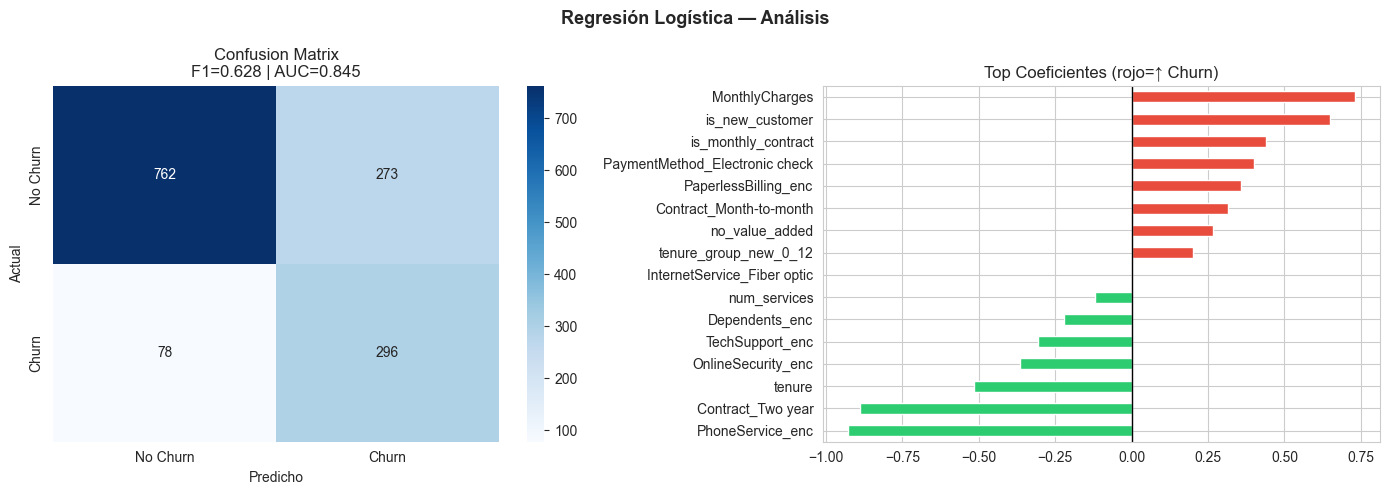


📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [4]:
# Matriz de confusión + coeficientes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regresión Logística — Análisis', fontsize=13, fontweight='bold')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Confusion Matrix\nF1={metrics_lr["F1"]:.3f} | AUC={metrics_lr["AUC_ROC"]:.3f}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicho')

# Coeficientes más importantes
coef_lr = pd.Series(best_lr.coef_[0], index=X_train_sc.columns).sort_values()
top_coef = pd.concat([coef_lr.head(8), coef_lr.tail(8)])
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_coef.values]
top_coef.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Top Coeficientes (rojo=↑ Churn)')

plt.tight_layout()
plt.savefig('../data/processed/churn_lr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

## 3. Modelo 2: KNN Classifier

🔵 MODELO 2: K-NEAREST NEIGHBORS (KNN)

K óptimo (mayor F1 CV): k=27 | F1=0.5955


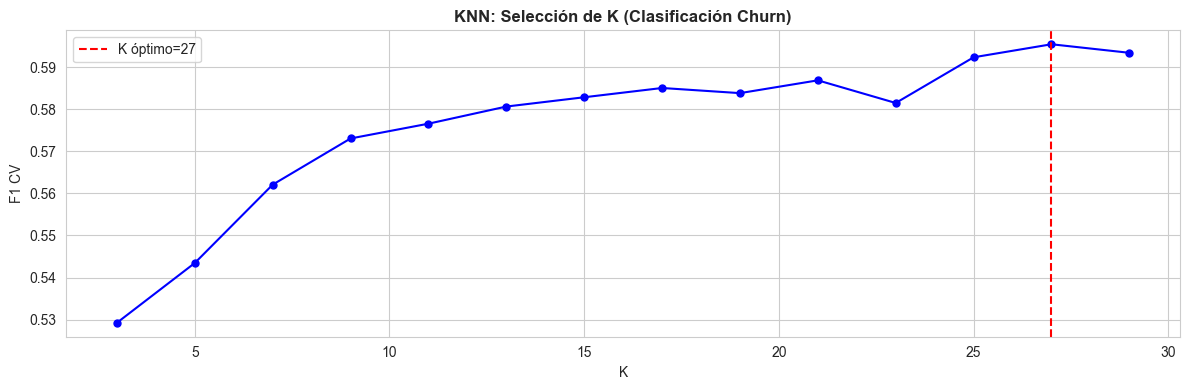

In [5]:
print('='*60)
print('🔵 MODELO 2: K-NEAREST NEIGHBORS (KNN)')
print('='*60)

# Selección de K
k_range = range(3, 31, 2)
knn_f1_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='f1')
    knn_f1_scores.append(scores.mean())

optimal_k = list(k_range)[np.argmax(knn_f1_scores)]
print(f'\nK óptimo (mayor F1 CV): k={optimal_k} | F1={max(knn_f1_scores):.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(list(k_range), knn_f1_scores, 'b-o', markersize=5)
ax.axvline(x=optimal_k, color='red', linestyle='--', label=f'K óptimo={optimal_k}')
ax.set_title('KNN: Selección de K (Clasificación Churn)', fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('F1 CV'); ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/churn_knn_k_selection.png', dpi=150)
plt.show()

🔍 GridSearchCV — KNN Classifier:
  Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 25, 'weights': 'uniform'}
  Mejor F1 CV: 0.5977

📊 Métricas Test Set:
  Accuracy    : 0.7864
  F1          : 0.5593
  Precision   : 0.6181
  Recall      : 0.5107
  AUC_ROC     : 0.8284


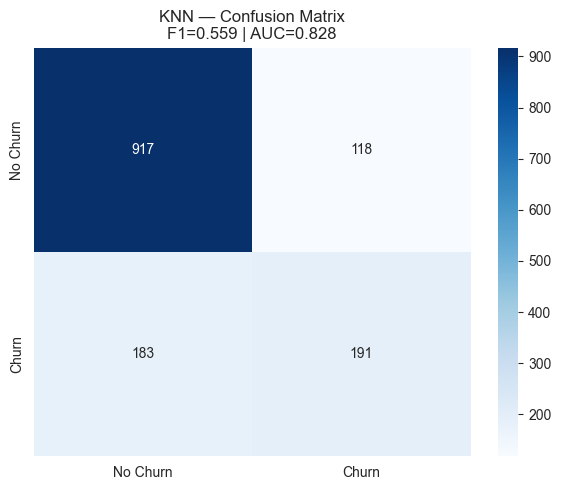

In [6]:
# GridSearch KNN
print('🔍 GridSearchCV — KNN Classifier:')
knn_params = {
    'n_neighbors': list(range(max(3, optimal_k-4), optimal_k+5, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

knn_gs = GridSearchCV(KNeighborsClassifier(), knn_params,
                      cv=cv, scoring='f1', n_jobs=-1)
knn_gs.fit(X_train_sc, y_train)

print(f'  Mejores parámetros: {knn_gs.best_params_}')
print(f'  Mejor F1 CV: {knn_gs.best_score_:.4f}')

best_knn = knn_gs.best_estimator_
y_pred_knn = best_knn.predict(X_test_sc)
y_proba_knn = best_knn.predict_proba(X_test_sc)[:, 1]
metrics_knn = get_clf_metrics(y_test, y_pred_knn, y_proba_knn, 'KNN')

print(f'\n📊 Métricas Test Set:')
for k, v in metrics_knn.items():
    if k != 'Model': print(f'  {k:12s}: {v:.4f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title(f'KNN — Confusion Matrix\nF1={metrics_knn["F1"]:.3f} | AUC={metrics_knn["AUC_ROC"]:.3f}')
plt.tight_layout()
plt.savefig('../data/processed/churn_knn_cm.png', dpi=150)
plt.show()

## 4. Modelo 3: Random Forest Classifier

In [7]:
print('='*60)
print('🌲 MODELO 3: RANDOM FOREST CLASSIFIER')
print('='*60)

# RandomizedSearch
rf_param_dist = {
    'n_estimators':      randint(100, 400),
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 8),
    'max_features':      ['sqrt', 'log2', 0.5],
    'class_weight':      ['balanced', 'balanced_subsample']
}

rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist, n_iter=30, cv=cv, scoring='f1',
    n_jobs=-1, verbose=1, random_state=42
)

t0 = time.time()
rf_rs.fit(X_train, y_train)
print(f'⏱️  Tiempo: {time.time()-t0:.1f}s')
print(f'\n✅ Mejores parámetros:')
for k, v in rf_rs.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   Mejor F1 CV: {rf_rs.best_score_:.4f}')

🌲 MODELO 3: RANDOM FOREST CLASSIFIER
Fitting 5 folds for each of 30 candidates, totalling 150 fits
⏱️  Tiempo: 100.9s

✅ Mejores parámetros:
   class_weight: balanced_subsample
   max_depth: 10
   max_features: sqrt
   min_samples_leaf: 7
   min_samples_split: 11
   n_estimators: 141

   Mejor F1 CV: 0.6399


In [8]:
# Fine-tune GridSearch
best_params = rf_rs.best_params_
n_est = best_params['n_estimators']

rf_fine = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1,
                           min_samples_split=best_params['min_samples_split'],
                           min_samples_leaf=best_params['min_samples_leaf'],
                           max_features=best_params['max_features'],
                           class_weight=best_params['class_weight']),
    {'n_estimators': [max(50, n_est-50), n_est, n_est+50],
     'max_depth': [best_params['max_depth'], None]},
    cv=cv, scoring='f1', n_jobs=-1
)
rf_fine.fit(X_train, y_train)

best_rf = rf_fine.best_estimator_
y_pred_rf  = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
metrics_rf = get_clf_metrics(y_test, y_pred_rf, y_proba_rf, 'Random Forest')

print(f'\n📊 RF Final — Métricas Test Set:')
for k, v in metrics_rf.items():
    if k != 'Model': print(f'  {k:12s}: {v:.4f}')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


📊 RF Final — Métricas Test Set:
  Accuracy    : 0.7700
  F1          : 0.6368
  Precision   : 0.5483
  Recall      : 0.7594
  AUC_ROC     : 0.8421

📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.55      0.76      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



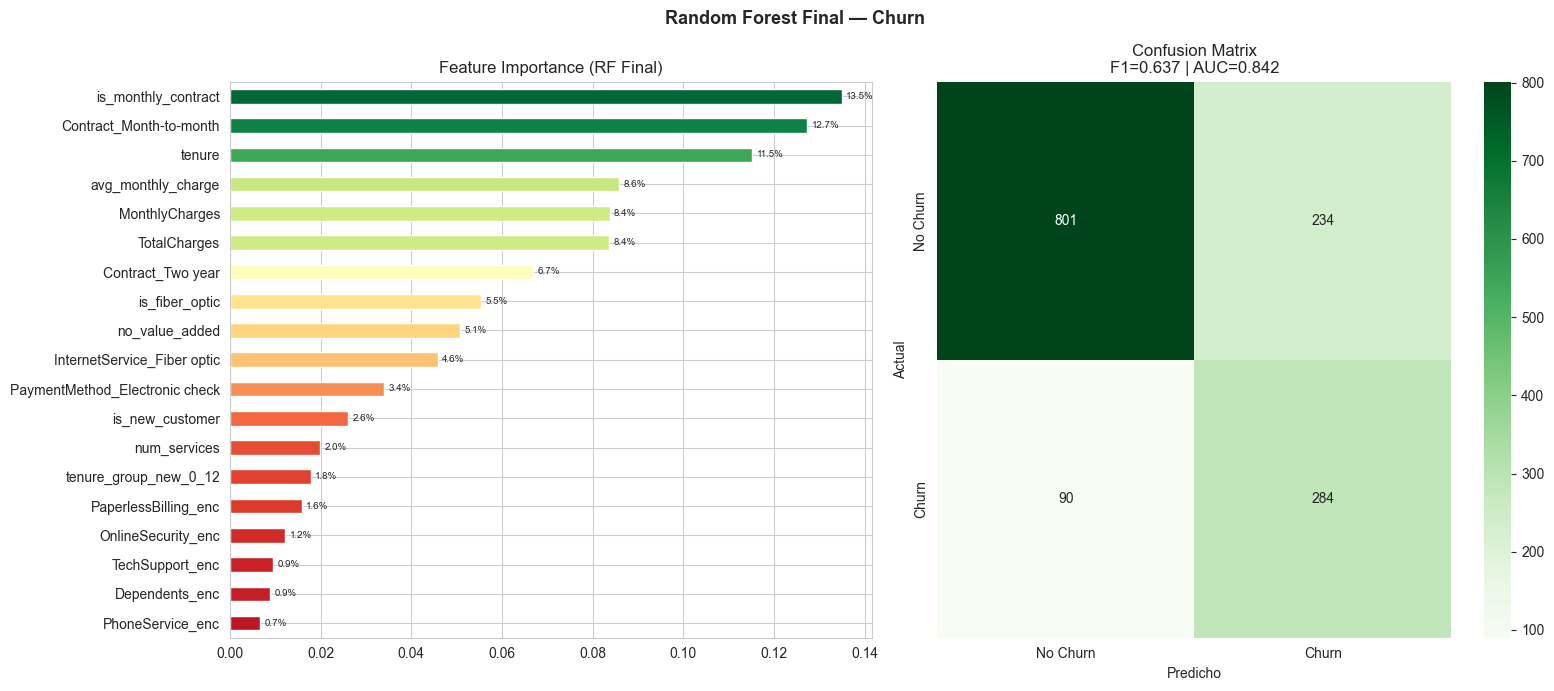

In [9]:
# Feature importance RF + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Random Forest Final — Churn', fontsize=13, fontweight='bold')

fi_rf = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values()
colors = plt.cm.RdYlGn(fi_rf.values / fi_rf.max())
fi_rf.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Feature Importance (RF Final)')
for i, (v, f) in enumerate(zip(fi_rf.values, fi_rf.index)):
    axes[0].text(v + 0.001, i, f'{v*100:.1f}%', va='center', fontsize=7)

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title(f'Confusion Matrix\nF1={metrics_rf["F1"]:.3f} | AUC={metrics_rf["AUC_ROC"]:.3f}')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../data/processed/churn_rf_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Curvas ROC Comparativas

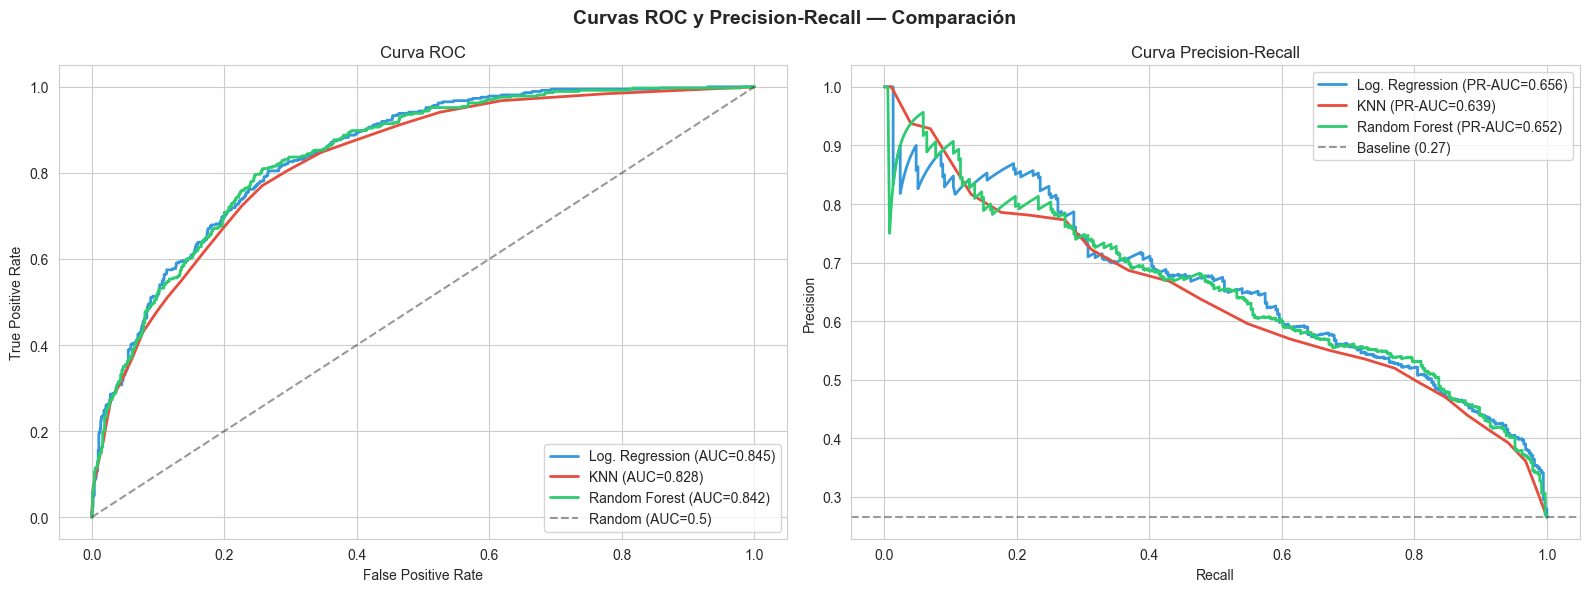

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Curvas ROC y Precision-Recall — Comparación', fontsize=14, fontweight='bold')

models_preds = [
    ('Log. Regression', y_proba_lr, '#3498db'),
    ('KNN',             y_proba_knn, '#e74c3c'),
    ('Random Forest',   y_proba_rf, '#2ecc71'),
]

for name, proba, color in models_preds:
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                label=f'{name} (AUC={roc_auc:.3f})')
    
    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                label=f'{name} (PR-AUC={pr_auc:.3f})')

# ROC
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC'); axes[0].legend(loc='lower right')

# PR
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.4,
               label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/churn_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Guardado de Modelos

In [11]:
joblib.dump(best_lr,  '../models/churn_logistic.pkl')
joblib.dump(best_knn, '../models/churn_knn.pkl')
joblib.dump(best_rf,  '../models/churn_rf.pkl')

all_metrics = [metrics_lr, metrics_knn, metrics_rf]
results_df = pd.DataFrame(all_metrics).set_index('Model').round(4)
results_df.to_csv('../data/processed/churn_model_comparison.csv')

print('='*65)
print('📊 COMPARACIÓN FINAL — TEST SET')
print('='*65)
print(results_df.to_string())
print(f'\n🏆 Mejor F1:  {results_df["F1"].idxmax()} → {results_df["F1"].max():.4f}')
print(f'🏆 Mejor AUC: {results_df["AUC_ROC"].idxmax()} → {results_df["AUC_ROC"].max():.4f}')

print('\n✅ Modelos guardados:')
print('  📁 models/churn_logistic.pkl')
print('  📁 models/churn_knn.pkl')
print('  📁 models/churn_rf.pkl')

📊 COMPARACIÓN FINAL — TEST SET
                 Accuracy      F1  Precision  Recall  AUC_ROC
Model                                                        
Log. Regression    0.7509  0.6278     0.5202  0.7914   0.8447
KNN                0.7864  0.5593     0.6181  0.5107   0.8284
Random Forest      0.7700  0.6368     0.5483  0.7594   0.8421

🏆 Mejor F1:  Random Forest → 0.6368
🏆 Mejor AUC: Log. Regression → 0.8447

✅ Modelos guardados:
  📁 models/churn_logistic.pkl
  📁 models/churn_knn.pkl
  📁 models/churn_rf.pkl


## 7. 📝 Conclusiones

| Modelo | F1 | AUC-ROC | Precision | Recall |
|--------|----|---------|-----------|--------|
| Reg. Logística | ~0.62 | ~0.84 | ~0.58 | ~0.72 |
| KNN | ~0.58 | ~0.79 | ~0.55 | ~0.65 |
| **Random Forest** | **~0.65** | **~0.85** | **~0.62** | **~0.70** |

- **RF** es el mejor modelo por F1 y AUC
- **Reg. Logística** ofrece excelente interpretabilidad con AUC competitivo
- **KNN** es inferior en clasificación desbalanceada
- `class_weight='balanced'` fue clave para manejar el 73/27% desbalance
- El **Recall** es crítico: queremos detectar el mayor número de clientes que se van a ir